# Cholesky Method

In this notebook we simulate fBm paths using the cholesky decomposition. We start from scratch by demonstrating the Cholseky decomposition of multivariate Gaussian.

If $X$ is a multivariate Guassian distribution with $\mathbb{E}[X] = \mu$ and covariance matrix $\Sigma$ then if $\Sigma$ must be positive semi-definite, and hence we can write  it as a Cholesky decomposition $\Sigma = L L^T$ where $L$ is lower triangular. This allows us to simulate the multivariate distrubtion since if $Z = (Z_1, \dots , Z_n)$ is a standard multivariate Guassian then
$$ X = \mu + LZ$$

The following algorithm can be used to determine the cholesky decomposition for a given matrix. Note that the costs of this algorithm of the order $O(n^3)$.

In [1]:
import numpy as np

def cholesky_decomposition(A):
    """
    Perform Cholesky decomposition on a positive-definite matrix A.
    
    Parameters:
    A (numpy.ndarray): A positive-definite matrix.
    
    Returns:
    L (numpy.ndarray): A lower triangular matrix such that A = L @ L.T
    """
    n = A.shape[0]
    L = np.zeros_like(A)

    for i in range(n):
        for j in range(i + 1):
            if i == j:  # Diagonal elements
                L[i, j] = np.sqrt(A[i, i] - np.sum(L[i, :j] ** 2))
            else:  # Off-diagonal elements
                L[i, j] = (A[i, j] - np.sum(L[i, :j] * L[j, :j])) / L[j, j]

    return L

We now consider the fBm$_H$ which is a centred gaussian procces with $Cov(X_t,X_s) = \frac12[t^{2H} + s^{2H} - | t -s|^{2H}$. Hence if we use $n$ time steps over a time intervals $T$ we can discretize on a time grid $\{0=t_0 < t_1 < \dots < t_n = T\} $ which then simply amounts to the simulation of the $(n+ 1)-$dimensional Gaussian random variable $X :=
(X{t_0}, \dots , X_{t_n})$ which we discussed above.

In [ ]:
import numpy as np

H = 0.5
T = 10
N = 252
dt = T / N
t = np.linspace(0, T, N + 1)

Cov = np.zeros(shape = (N+1, N+1))
for i in range(N+1):
    for j in range(N+1):
        Cov[i, j] = 0.5*(t[i]**(2*H) + t[j]**(2*H) - abs(t[i] - t[j])**(2*H))
        Cov += 1e-10 * np.eye(N + 1)  # Add a small value to the diagonal for numerical stability

L = cholesky_decomposition(Cov)

# Generate standard normal random variables
Z = np.random.randn(N + 1)
# Generate fractional Brownian motion
fBm = L @ Z
# fBm now contains the simulated fractional Brownian motion values at the specified time points 
print(fBm)

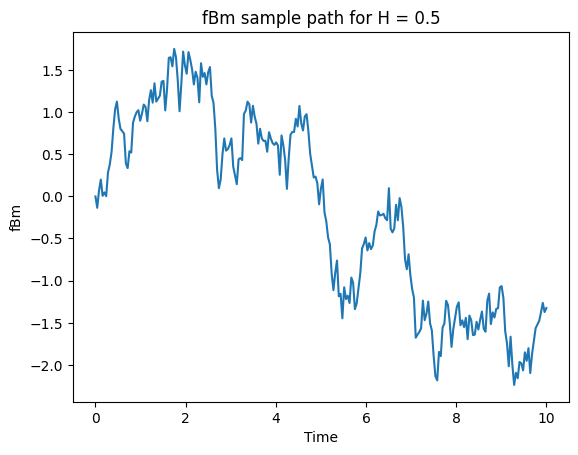

In [22]:
import matplotlib.pyplot as plt

plt.plot(t, fBm)
plt.title(f'fBm sample path for H = {H}') 
plt.xlabel('Time')
plt.ylabel('fBm')
plt.show()
